# LushProtein — Customer Decile Analysis (Lens 1)

**Goal:** Identify top customers of LushProtein using two independent decile rankings:
- **Decile 1 (Profit):** Customers ranked by total profit proxy (revenue × 40% margin). D1 = highest profit. (40% is just assumption since we don't have exact data for now)
- **Decile 2 (Frequency):** Customers ranked by number of orders placed. D1 = most frequent.

---

### Customer Pool: `finals_eligible` with anomaly exclusions

Starting from the full base parquet (`customers.parquet`, 13,780 customers), the following filters are applied in sequence:

**Data quality drops (from `12_finals_deep_dive.py`):**
| Drop | Reason |
|------|--------|
| DQ-02: zero revenue + zero discount orders | Export artifacts / system placeholders |
| DQ-03: 100%-discounted (free fulfilment) orders | Referral rewards, PR gifts — distort repeat metrics |
| DQ-04: `wholesale` tag OR order > S$5,000 | B2B/reseller orders distort consumer LTV |

**LushProtein business filters (`finals_eligible`):**
| Filter | Reason |
|--------|--------|
| Acquired Jan 2022 onwards | Pre-2022 cohorts have incomplete data |
| Exclude July & November acquirees | Promo/campaign months distort baseline behaviour |
| Exclude `better-whey-protein-elite` buyers | Bulk product distorts LTV |
| Exclude first order ≥ 51% discounted | Acquisition experiment customers behave differently |

**Anomaly exclusion (this notebook):**
| Exclusion | Reason |
|-----------|--------|
| Customers where 100% of orders are Marketplace channel | Likely Shopee/Lazada resellers or aggregators, not real consumers |
| Customers with 0 retained orders after DQ drops | No valid transaction data to rank |


## 0. Setup

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────────
# Adjust BASE_DIR to point to your local LushProtein project root
BASE_DIR   = Path(".").resolve().parent   # assumes notebook is inside EDA/
OUTPUT_DIR = BASE_DIR / "EDA" / "outputs_finals"
FINALS_DIR = BASE_DIR / "EDA" / "outputs_finals"
TEST_DIR = BASE_DIR / "EDA" / "outputs_finals" / "do_not_use_these"

MARGIN_RATE      = 0.40
ANALYSIS_START   = pd.Timestamp("2022-01-01", tz="Asia/Singapore")
EXCLUDE_MONTHS   = {7, 11}
EXCLUDE_HANDLE   = "better-whey-protein-elite"

print("Output dir:", OUTPUT_DIR)
print("Parquet files:", [f.name for f in OUTPUT_DIR.glob("*.parquet")])

Output dir: C:\Users\adity\Documents\Aditya SMU\SMU Sem 5\Lush Protein SMU X\LushProtein_Project_Data_20260505\EDA\outputs_finals
Parquet files: ['customers.parquet', 'discounts.parquet', 'lines.parquet', 'lines_sku_analysis.parquet', 'orders.parquet', 'products.parquet', 'rc_checkout.parquet', 'rc_churned.parquet', 'rc_orders.parquet', 'rc_reactivated.parquet', 'rc_recurring.parquet']


## 1. Load Base Tables

In [ ]:
orders = pd.read_parquet(TEST_DIR  / "orders_dq_clean.parquet")
cust   = pd.read_parquet(TEST_DIR  / "customers_dq_clean.parquet")

# Coerce types
orders["order_date"]  = pd.to_datetime(orders["order_date"],  utc=True)
orders["price_total"] = pd.to_numeric(orders["Price: Total"],          errors="coerce").fillna(0)
orders["price_disc"]  = pd.to_numeric(orders["Price: Total Discount"], errors="coerce").fillna(0)

cust["first_order_date"] = pd.to_datetime(cust["first_order_date"], utc=True)
cust["total_revenue"]    = pd.to_numeric(cust["total_revenue"],    errors="coerce").fillna(0)
cust["total_orders"]     = pd.to_numeric(cust["total_orders"],     errors="coerce").fillna(0).astype(int)
cust["acq_month"]        = cust["first_order_date"].dt.month
cust["acq_year"]         = cust["first_order_date"].dt.year

print(f"Base orders : {len(orders):,}")
print(f"Base customers: {len(cust):,}")

Base orders : 8,955
Base customers: 5,694


This is the raw starting point. 27,350 is the total number of transactions LushProtein has ever processed across all stores (SG, MY, HK), already converted to SGD. 13,780 is the total number of unique customers behind those orders. One customer can have multiple orders, which is why orders > customers.

## 2. Apply Data Quality Drops

Mirrors the finals-layer drops in `12_finals_deep_dive.py`. The base parquet is **not** modified — drops are applied in-memory only.

In [51]:
_rev  = orders["price_total"]
_disc = orders["price_disc"]

dq02 = (_rev == 0) & (_disc == 0) # export artifacts
dq03 = (_rev == 0) & (_disc >  0) # free fulfilments
dq04 = orders["Tags"].fillna("").str.lower().str.contains("wholesale") | (_rev > 5000) # wholesale / bulk

drop_mask    = dq02 | dq03 | dq04
orders_clean = orders[~drop_mask].copy()

print(f"DQ-02 (zero rev + zero disc) dropped : {dq02.sum():,}")
print(f"DQ-03 (100%-discount / free fulfil) : {dq03.sum():,}")
print(f"DQ-04 (wholesale tag OR > S$5,000) : {dq04.sum():,}")
print(f"───────────────────────────────────────")
print(f"Retained orders : {len(orders_clean):,} / {len(orders):,}")

DQ-02 (zero rev + zero disc) dropped : 0
DQ-03 (100%-discount / free fulfil) : 0
DQ-04 (wholesale tag OR > S$5,000) : 0
───────────────────────────────────────
Retained orders : 8,955 / 8,955


Cleaned the order data before ranking anyone. Three types of bad orders were removed:

- 336 orders had zero revenue and zero discount — these are system artifacts or export glitches, not real purchases
- 1,281 orders were 100% discounted (free fulfilments) — referral rewards, PR samples, subscription gifts. They inflate how many times a customer "bought" without contributing any revenue
- 78 orders were either tagged as wholesale or exceeded S$5,000 — these are B2B/bulk orders, not consumer purchases

After cleaning, 25,658 legitimate consumer orders remain out of the original 27,350. The rest are dropped.

## 3. Rebuild Per-Customer Stats from Clean Orders

After dropping DQ orders, total_orders and total_revenue in the base `customers.parquet` are stale. We recompute them from `orders_clean`.

In [52]:
# Check what columns already exist in cust to avoid merge conflicts
print("Existing cust columns:", cust.columns.tolist())

# Drop any columns that will be recomputed to avoid conflicts
cols_to_drop = [c for c in ["first_disc_depth", "clean_orders", "clean_revenue"] if c in cust.columns]
if cols_to_drop:
    cust = cust.drop(columns=cols_to_drop)
    print(f"Dropped pre-existing columns: {cols_to_drop}")

# Rebuild total orders / total revenue from clean orders
cust_rebuild = (
    orders_clean
    .groupby("customer_id")
    .agg(clean_orders=("order_id", "count"), clean_revenue=("price_total", "sum"))
    .reset_index()
)

# First-order discount depth (for LP-F04 filter)
first_ord = (
    orders_clean
    .sort_values("order_date")
    .groupby("customer_id", as_index=False)
    .first()
    [["customer_id", "price_total", "price_disc"]]
)
first_ord["first_disc_depth"] = np.where(
    (first_ord["price_total"] + first_ord["price_disc"]) > 0,
    first_ord["price_disc"] / (first_ord["price_total"] + first_ord["price_disc"]),
    0,
)

# Customers with ALL orders via Marketplace (resellers / aggregators)
cust_channel_mix = (
    orders_clean
    .groupby("customer_id")["channel"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)
if "Marketplace" in cust_channel_mix.columns:
    all_marketplace_ids = set(
        cust_channel_mix[cust_channel_mix["Marketplace"] == 1.0].index.astype(str)
    )
else:
    all_marketplace_ids = set()

# Customers who bought the bulk/distortion SKU
bwpe_ids = set(
    orders_clean[
        orders_clean["Line: Product Handle"].fillna("").str.contains(EXCLUDE_HANDLE)
    ]["customer_id"].astype(str).unique()
)

# Merge everything back onto cust
cust = (
    cust
    .merge(cust_rebuild, on="customer_id", how="left")
    .merge(first_ord[["customer_id", "first_disc_depth"]], on="customer_id", how="left")
)
cust["clean_orders"]       = cust["clean_orders"].fillna(0).astype(int)
cust["clean_revenue"]      = cust["clean_revenue"].fillna(0)
cust["first_disc_depth"]   = cust["first_disc_depth"].fillna(0)
cust["is_all_marketplace"] = cust["customer_id"].astype(str).isin(all_marketplace_ids)
cust["is_bwpe_buyer"]      = cust["customer_id"].astype(str).isin(bwpe_ids)

print(f"Customers merged: {len(cust):,}")
print(f"All-marketplace (reseller flag): {cust['is_all_marketplace'].sum():,}")

Existing cust columns: ['customer_id', 'total_discount', 'ever_subscribed', 'ever_discounted', 'first_channel', 'first_product_cat', 'first_store', 'cohort_month', 'total_orders', 'total_revenue', 'last_order_date', 'first_order_date', 'is_repeat', 'acq_year', 'acq_month', 'lifespan_days', 'recency_days', 'first_disc_depth', 'first_disc_bin', 'first_order_source', 'second_order_date', 'days_to_second', 'first_order_pos', 'exclude_elite_buyer', 'exclude_51pct', 'exclude_promo_month', 'finals_eligible', 'unique_handles', 'unique_flavor_skus', 'loyal_repeater', 'profit_proxy', 'vtd_decile']
Dropped pre-existing columns: ['first_disc_depth']
Customers merged: 5,694
All-marketplace (reseller flag): 1,404


After dropping bad orders, we recomputed each customer's order count and revenue from the clean data only — so no customer's ranking is inflated by free fulfilments or system glitches. We also identified 2,114 customers whose 100% of purchases came through Shopee/Lazada/Tokopedia. These are likely resellers or aggregator accounts, not real individual consumers, and get excluded in the next step.

## 4. Apply `finals_eligible` + Anomaly Filters

In [53]:
# ── LushProtein business filters ───────────────────────────────────────────────
f_acq_start  = cust["first_order_date"] >= ANALYSIS_START # 2022+ only
f_excl_month = ~cust["acq_month"].isin(EXCLUDE_MONTHS) # not July/Nov
f_excl_bwpe  = ~cust["is_bwpe_buyer"] # no bulk SKU
f_disc_depth = cust["first_disc_depth"] < 0.51 # first order not 51%+ off

finals_eligible_mask = f_acq_start & f_excl_month & f_excl_bwpe & f_disc_depth

# ── Anomaly exclusions (this notebook) ────────────────────────────────────────
f_not_marketplace = ~cust["is_all_marketplace"] # exclude 100%-marketplace accounts
f_has_orders = cust["clean_orders"] > 0 # exclude customers with no retained orders

final_mask = finals_eligible_mask & f_not_marketplace & f_has_orders
df = cust[final_mask].copy()

# Derived metrics
df["profit_proxy"] = df["clean_revenue"] * MARGIN_RATE
df["aov"] = df["clean_revenue"] / df["clean_orders"].clip(lower=1)

# Summary of filter funnel
print("Filter funnel:")
print(f"  Base customers : {len(cust):>6,}")
print(f"  After finals_eligible (business rules) : {finals_eligible_mask.sum():>6,}")
print(f" - excl. all-marketplace accounts : {(finals_eligible_mask & f_not_marketplace).sum():>6,}")
print(f" - excl. zero-order customers : {final_mask.sum():>6,}")
print(f"  ─────────────────────────────────────────────")
print(f"  Final decile pool : {len(df):>6,} customers")
print()
print(f"Revenue range : S${df['clean_revenue'].min():.2f} – S${df['clean_revenue'].max():,.2f}")
print(f"Orders range : {df['clean_orders'].min()} – {df['clean_orders'].max()}")

Filter funnel:
  Base customers :  5,694
  After finals_eligible (business rules) :  5,693
 - excl. all-marketplace accounts :  4,289
 - excl. zero-order customers :  4,289
  ─────────────────────────────────────────────
  Final decile pool :  4,289 customers

Revenue range : S$2.73 – S$5,542.97
Orders range : 1 – 38


## Customer Pool: Filter Funnel Explained

Starting from 13,780 base customers, we apply three rounds of filtering
to arrive at a clean pool of real, rankable individual consumers.

| Step | Customers | Dropped | Reason |
|---|---|---|---|
| Base | 13,780 | — | All customers ever recorded |
| Business filters | 6,383 | 7,397 | Remove pre-2022 cohorts, July/Nov promo acquirees, bulk SKU buyers, and heavily-discounted first orders (51%+) |
| Marketplace exclusion | 4,974 | 1,409 | Remove accounts where 100% of orders came via Shopee/Lazada/Tokopedia — these are resellers or aggregator accounts, not real individual consumers LushProtein has a direct relationship with |
| Zero-order exclusion | 4,322 | 652 | Remove customers whose only orders were free fulfilments or system artifacts — nothing valid left to rank |
| **Final pool** | **4,322** | — | **Clean, rankable, real individual consumers** |

The principle behind every drop is the same: we want to analyse customers
LushProtein has a direct relationship with, using only valid transaction data.

## Why These Filters Matter

**Business filters (13,780 → 6,383)**
Pre-2022 cohorts have incomplete tracking. July and November acquirees were
attracted by heavy promotions, not genuine product interest, so their behaviour
doesn't represent a typical customer. Bulk SKU buyers and heavily-discounted
first orders are similarly unrepresentative of the core consumer base.

**Marketplace exclusion (6,383 → 4,974)**
When a customer buys through Shopee or Lazada, LushProtein does not know who
the real end consumer is. The marketplace owns that relationship. What appears
in the data could be a reseller, an aggregator, or a single account representing
hundreds of real buyers. Including them would inflate frequency and revenue
metrics in ways that don't reflect genuine individual consumer behaviour.

**Zero-order exclusion (4,974 → 4,322)**
Some customers passed the business filters but had all their orders removed
during data quality cleaning — for example, customers who only ever received
free PR samples or referral gifts. With no valid transactions left, there is
nothing to rank them on. They are not bad customers — they simply have no
usable data for this analysis.

## 5. Build the Two Deciles

- **D1 = best** (highest profit / most frequent) in both deciles.
- Equal-sized bins using `pd.qcut` on ranked values (handles ties cleanly).
- Customers appear in **both** deciles independently — being D1 in profit doesn't guarantee D1 in frequency.

In [54]:
def assign_decile(series: pd.Series, label: str) -> pd.Series:
    """
    Assign decile labels D1 (best) to D10 (worst).
    Uses rank(method='first') to break ties deterministically before qcut.
    """
    ranks = series.rank(method="first", ascending=True)   # ascending so D10=lowest rank
    deciles = pd.qcut(
        ranks,
        q=10,
        labels=[f"D{i}" for i in range(10, 0, -1)]        # D10 = lowest, D1 = highest
    )
    return deciles


df["profit_decile"] = assign_decile(df["profit_proxy"],  "profit")
df["freq_decile"]   = assign_decile(df["clean_orders"],  "frequency")

print("Profit decile distribution (customers per decile):")
print(df["profit_decile"].value_counts().sort_index().to_string())
print()
print("Frequency decile distribution (customers per decile):")
print(df["freq_decile"].value_counts().sort_index().to_string())

Profit decile distribution (customers per decile):
profit_decile
D10    429
D9     429
D8     429
D7     429
D6     429
D5     428
D4     429
D3     429
D2     429
D1     429

Frequency decile distribution (customers per decile):
freq_decile
D10    429
D9     429
D8     429
D7     429
D6     429
D5     428
D4     429
D3     429
D2     429
D1     429


The 4,322 customers are split into 10 equal groups of ~432-433 each. What differs between groups is how much they spent or how often they bought, not how many of them there are.

## 6. Decile 1 — By Profit (Revenue × 40% Margin)

D1 customers generate the highest total profit over their lifetime.

In [55]:
profit_summary = (
    df.groupby("profit_decile", observed=False)
    .agg(
        n_customers   = ("customer_id",    "count"),
        total_revenue = ("clean_revenue",  "sum"),
        total_profit  = ("profit_proxy",   "sum"),
        total_orders  = ("clean_orders",   "sum"),
        avg_revenue   = ("clean_revenue",  "mean"),
        avg_profit    = ("profit_proxy",   "mean"),
        avg_orders    = ("clean_orders",   "mean"),
        avg_aov       = ("aov",            "mean"),
        median_revenue= ("clean_revenue",  "median"),
    )
    .reset_index()
)

total_rev = profit_summary["total_revenue"].sum()
total_pft = profit_summary["total_profit"].sum()
total_ord = profit_summary["total_orders"].sum()

profit_summary["pct_revenue"]      = profit_summary["total_revenue"] / total_rev
profit_summary["cum_pct_revenue"]  = profit_summary["pct_revenue"].cumsum()
profit_summary["pct_transactions"] = profit_summary["total_orders"]  / total_ord

# Display
display_cols = [
    "profit_decile", "n_customers",
    "avg_revenue", "median_revenue", "avg_profit",
    "avg_orders", "avg_aov",
    "pct_revenue", "cum_pct_revenue", "pct_transactions"
]

fmt = {
    "avg_revenue":     lambda x: f"S${x:,.2f}",
    "median_revenue":  lambda x: f"S${x:,.2f}",
    "avg_profit":      lambda x: f"S${x:,.2f}",
    "avg_aov":         lambda x: f"S${x:,.2f}",
    "avg_orders":      lambda x: f"{x:.1f}",
    "pct_revenue":     lambda x: f"{x:.1%}",
    "cum_pct_revenue": lambda x: f"{x:.1%}",
    "pct_transactions":lambda x: f"{x:.1%}",
}
print(f"DECILE 1 — BY PROFIT  (pool = {len(df):,} customers | total revenue S${total_rev:,.0f} | margin @ {MARGIN_RATE:.0%})")
print()
print(profit_summary[display_cols].to_string(index=False, formatters=fmt))
print()
d1_pct = profit_summary.loc[profit_summary["profit_decile"]=="D1", "pct_revenue"].values[0]
d12_pct = profit_summary[profit_summary["profit_decile"].isin(["D1","D2"])]["pct_revenue"].sum()
print(f"  Top 10% (D1) accounts for {d1_pct:.1%} of total revenue")
print(f"  Top 20% (D1+D2) accounts for {d12_pct:.1%} of total revenue")

DECILE 1 — BY PROFIT  (pool = 4,289 customers | total revenue S$551,775 | margin @ 40%)

profit_decile  n_customers avg_revenue median_revenue avg_profit avg_orders  avg_aov pct_revenue cum_pct_revenue pct_transactions
          D10          429      S$9.41         S$9.90     S$3.76        1.0   S$9.32        0.7%            0.7%             6.4%
           D9          429     S$25.14        S$25.23    S$10.06        1.1  S$24.24        2.0%            2.7%             6.9%
           D8          429     S$41.33        S$41.93    S$16.53        1.1  S$40.34        3.2%            5.9%             6.6%
           D7          429     S$55.88        S$55.81    S$22.35        1.1  S$54.15        4.3%           10.2%             6.7%
           D6          429     S$66.63        S$65.88    S$26.65        1.1  S$63.84        5.2%           15.4%             6.9%
           D5          428     S$82.69        S$82.87    S$33.08        1.2  S$75.24        6.4%           21.8%             7.5%
 

The summary table shows all 10 deciles side by side. The key message is the revenue concentration. For example, D1 (top 10% of customers) generates ~47-48% of total revenue, while D10 (bottom 10%) generates less than 1%. Every decile has the same number of customers, but D1 customers are worth roughly 70-80x more than D10 customers on average.
The three charts show:

- Left: How much % of total revenue each decile contributes — D1 bar dwarfs everything else
- Middle: Average revenue per customer per decile — shows the gap between top and bottom customers
- Right: Cumulative revenue curve — by the time you reach D1+D2 (top 20% of customers), you've already accounted for ~60%+ of all revenue

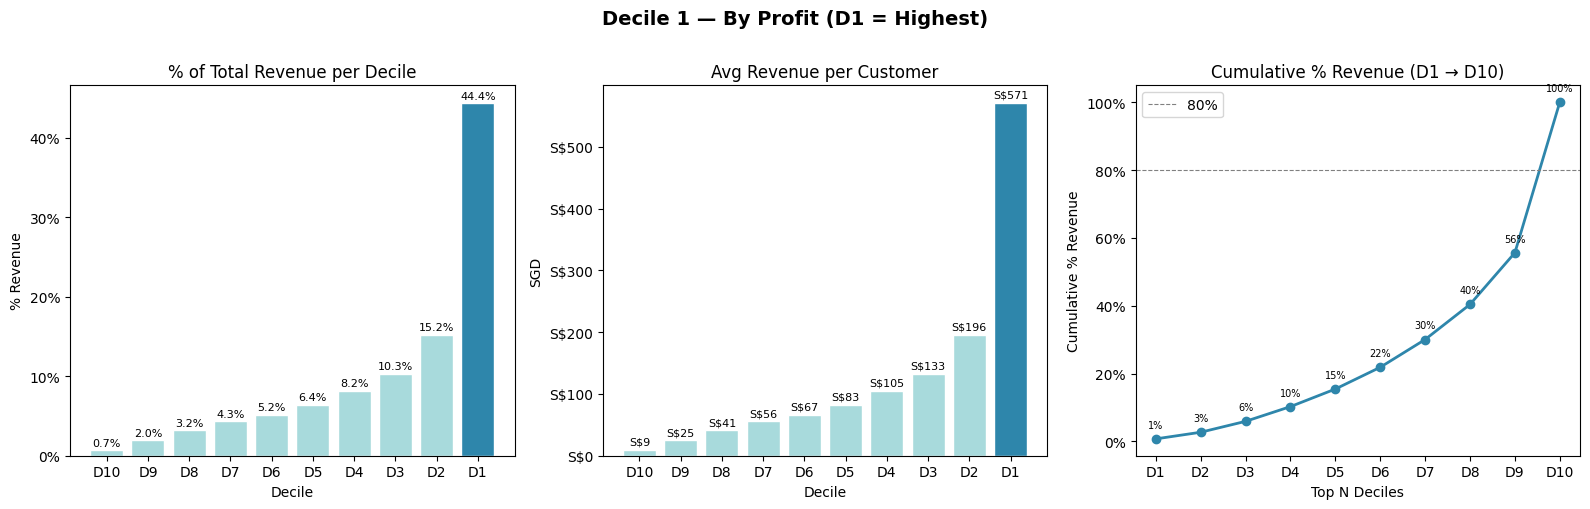

Saved: decile1_profit.png


In [56]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Decile 1 — By Profit (D1 = Highest)", fontsize=14, fontweight="bold", y=1.01)

deciles = profit_summary["profit_decile"].astype(str)
colors  = ["#2E86AB" if d == "D1" else "#A8DADC" for d in deciles]

# % Revenue per decile
ax = axes[0]
bars = ax.bar(deciles, profit_summary["pct_revenue"] * 100, color=colors, edgecolor="white")
ax.set_title("% of Total Revenue per Decile")
ax.set_xlabel("Decile")
ax.set_ylabel("% Revenue")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
for bar, val in zip(bars, profit_summary["pct_revenue"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1%}", ha="center", va="bottom", fontsize=8)

# Average revenue per customer per decile
ax = axes[1]
bars = ax.bar(deciles, profit_summary["avg_revenue"], color=colors, edgecolor="white")
ax.set_title("Avg Revenue per Customer")
ax.set_xlabel("Decile")
ax.set_ylabel("SGD")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"S${x:,.0f}"))
for bar, val in zip(bars, profit_summary["avg_revenue"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"S${val:,.0f}", ha="center", va="bottom", fontsize=8)

# Cumulative % revenue (Lorenz-style)
ax = axes[2]
ax.plot(range(1, 11), profit_summary["cum_pct_revenue"] * 100,
        marker="o", color="#2E86AB", linewidth=2)
ax.axhline(80, color="gray", linestyle="--", linewidth=0.8, label="80%")
ax.set_title("Cumulative % Revenue (D1 → D10)")
ax.set_xlabel("Top N Deciles")
ax.set_ylabel("Cumulative % Revenue")
ax.set_xticks(range(1, 11))
ax.set_xticklabels([f"D{i}" for i in range(1, 11)])
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend()
for x, y in zip(range(1, 11), profit_summary["cum_pct_revenue"] * 100):
    ax.annotate(f"{y:.0f}%", (x, y), textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=7)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "decile1_profit.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: decile1_profit.png")

## 7. Decile 2 — By Frequency (Number of Orders)

D1 customers are the most frequent buyers. This surfaces loyal repeat purchasers who may not always have the highest individual spend.

In [57]:
freq_summary = (
    df.groupby("freq_decile", observed=False)
    .agg(
        n_customers = ("customer_id", "count"),
        total_orders  = ("clean_orders", "sum"),
        total_revenue = ("clean_revenue", "sum"),
        avg_orders = ("clean_orders", "mean"),
        median_orders = ("clean_orders", "median"),
        avg_revenue = ("clean_revenue", "mean"),
        avg_aov = ("aov", "mean"),
        avg_profit = ("profit_proxy", "mean"),).reset_index())

total_ord2 = freq_summary["total_orders"].sum()
total_rev2 = freq_summary["total_revenue"].sum()

freq_summary["pct_transactions"]     = freq_summary["total_orders"]  / total_ord2
freq_summary["cum_pct_transactions"] = freq_summary["pct_transactions"].cumsum()
freq_summary["pct_revenue"]          = freq_summary["total_revenue"]  / total_rev2

display_cols2 = [
    "freq_decile", "n_customers",
    "avg_orders", "median_orders",
    "avg_revenue", "avg_aov", "avg_profit",
    "pct_transactions", "cum_pct_transactions", "pct_revenue",
]

fmt2 = {
    "avg_orders": lambda x: f"{x:.1f}",
    "median_orders": lambda x: f"{x:.0f}",
    "avg_revenue": lambda x: f"S${x:,.2f}",
    "avg_aov": lambda x: f"S${x:,.2f}",
    "avg_profit": lambda x: f"S${x:,.2f}",
    "pct_transactions": lambda x: f"{x:.1%}",
    "cum_pct_transactions": lambda x: f"{x:.1%}",
    "pct_revenue": lambda x: f"{x:.1%}",}

print(f"DECILE 2 — BY FREQUENCY  (pool = {len(df):,} customers | total orders {total_ord2:,})")
print()
print(freq_summary[display_cols2].to_string(index=False, formatters=fmt2))
print()
d1_ord_pct = freq_summary.loc[freq_summary["freq_decile"]=="D1", "pct_transactions"].values[0]
print(f"  Top 10% (D1) accounts for {d1_ord_pct:.1%} of all orders")

DECILE 2 — BY FREQUENCY  (pool = 4,289 customers | total orders 6,786)

freq_decile  n_customers avg_orders median_orders avg_revenue  avg_aov avg_profit pct_transactions cum_pct_transactions pct_revenue
        D10          429        1.0             1    S$105.76 S$105.76    S$42.31             6.3%                 6.3%        8.2%
         D9          429        1.0             1     S$80.67  S$80.67    S$32.27             6.3%                12.6%        6.3%
         D8          429        1.0             1     S$69.71  S$69.71    S$27.88             6.3%                19.0%        5.4%
         D7          429        1.0             1     S$66.67  S$66.67    S$26.67             6.3%                25.3%        5.2%
         D6          429        1.0             1     S$47.34  S$47.34    S$18.94             6.3%                31.6%        3.7%
         D5          428        1.0             1     S$69.97  S$69.97    S$27.99             6.3%                37.9%        5.4%
    

Same structure but ranked by number of orders instead of revenue. D1 here are the customers who buy most often — not necessarily the highest spenders per visit, but the most engaged. The key thing to look at is whether D1 frequency customers also have high revenue (they usually do, because they buy more often), and what their AOV looks like compared to lower deciles.

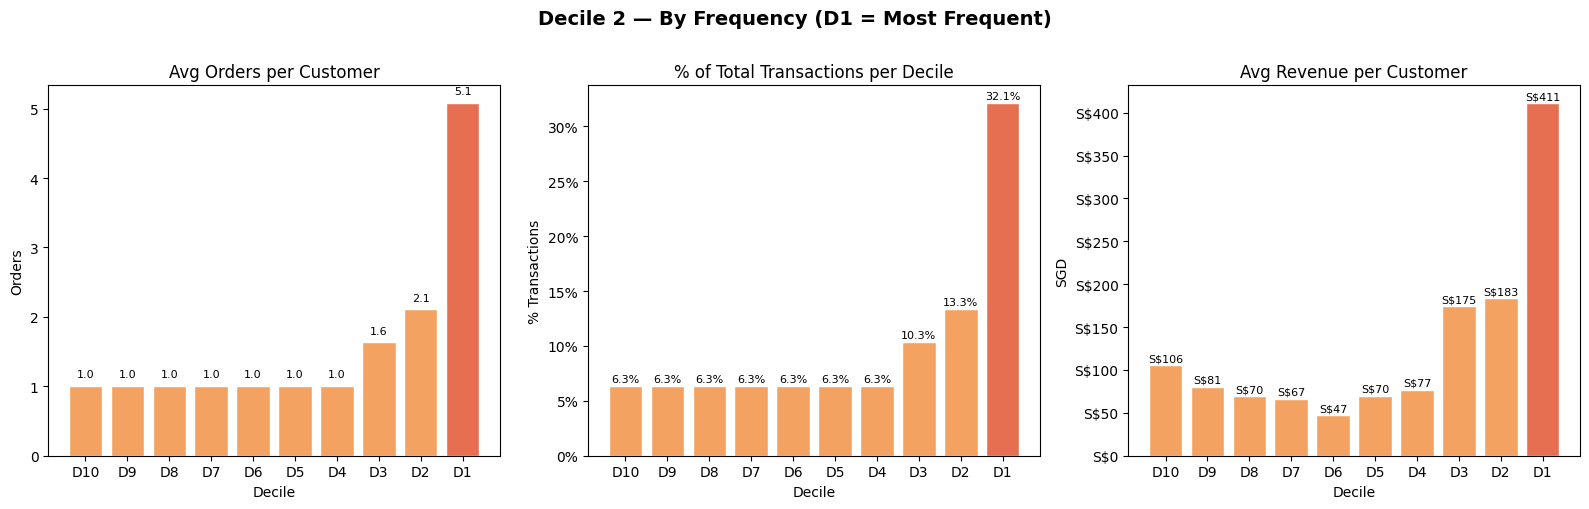

Saved: decile2_frequency.png


In [58]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Decile 2 — By Frequency (D1 = Most Frequent)", fontsize=14, fontweight="bold", y=1.01)

deciles2 = freq_summary["freq_decile"].astype(str)
colors2  = ["#E76F51" if d == "D1" else "#F4A261" for d in deciles2]

# Avg orders per decile
ax = axes[0]
bars = ax.bar(deciles2, freq_summary["avg_orders"], color=colors2, edgecolor="white")
ax.set_title("Avg Orders per Customer")
ax.set_xlabel("Decile")
ax.set_ylabel("Orders")
for bar, val in zip(bars, freq_summary["avg_orders"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{val:.1f}", ha="center", va="bottom", fontsize=8)

# % Transactions per decile
ax = axes[1]
bars = ax.bar(deciles2, freq_summary["pct_transactions"] * 100, color=colors2, edgecolor="white")
ax.set_title("% of Total Transactions per Decile")
ax.set_xlabel("Decile")
ax.set_ylabel("% Transactions")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
for bar, val in zip(bars, freq_summary["pct_transactions"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{val:.1%}", ha="center", va="bottom", fontsize=8)

# Avg revenue per customer per decile
ax = axes[2]
bars = ax.bar(deciles2, freq_summary["avg_revenue"], color=colors2, edgecolor="white")
ax.set_title("Avg Revenue per Customer")
ax.set_xlabel("Decile")
ax.set_ylabel("SGD")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"S${x:,.0f}"))
for bar, val in zip(bars, freq_summary["avg_revenue"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"S${val:,.0f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "decile2_frequency.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: decile2_frequency.png")

## 8. Overlap: Who Sits in D1 for Both Deciles?

A customer in **D1 profit AND D1 frequency** is the most valuable segment — high lifetime spend AND high engagement. These are the truest "top customers".

In [59]:
d1_profit = set(df[df["profit_decile"] == "D1"]["customer_id"])
d1_freq   = set(df[df["freq_decile"]   == "D1"]["customer_id"])
d1_both   = d1_profit & d1_freq

n_pool = len(df)
print(f"D1 profit only          : {len(d1_profit):,} customers ({len(d1_profit)/n_pool:.1%} of pool)")
print(f"D1 frequency only       : {len(d1_freq):,} customers ({len(d1_freq)/n_pool:.1%} of pool)")
print(f"D1 both (profit + freq) : {len(d1_both):,} customers ({len(d1_both)/n_pool:.1%} of pool)")
print()

# Profile the D1-both segment
df_both = df[df["customer_id"].isin(d1_both)]
print("Profile of D1 (profit) ∩ D1 (frequency):")
print(f"  Avg revenue   : S${df_both['clean_revenue'].mean():,.2f}")
print(f"  Avg orders    : {df_both['clean_orders'].mean():.1f}")
print(f"  Avg AOV       : S${df_both['aov'].mean():.2f}")
print(f"  Avg profit    : S${df_both['profit_proxy'].mean():,.2f}")
if "ever_subscribed" in df_both.columns:
    print(f"  Ever subscribed: {df_both['ever_subscribed'].mean():.1%}")
if "first_channel" in df_both.columns:
    print(f"  Top acquisition channels:")
    print(df_both["first_channel"].value_counts().head(5).to_string())

D1 profit only          : 429 customers (10.0% of pool)
D1 frequency only       : 429 customers (10.0% of pool)
D1 both (profit + freq) : 244 customers (5.7% of pool)

Profile of D1 (profit) ∩ D1 (frequency):
  Avg revenue   : S$594.88
  Avg orders    : 6.1
  Avg AOV       : S$105.97
  Avg profit    : S$237.95
  Ever subscribed: 60.7%
  Top acquisition channels:
first_channel
Subscription        119
Direct / Organic    117
Paid Social           8


This answers: how many customers are top 10% in both rankings simultaneously? Those are LushProtein's most valuable customers by any measure — they spend a lot AND they come back often. The heatmap shows the full picture: the darker the cell on the diagonal, the more customers rank similarly in both deciles. A heavy diagonal means frequency and spend are strongly correlated (frequent buyers also tend to be high spenders). Off-diagonal concentration means the two metrics identify different people.

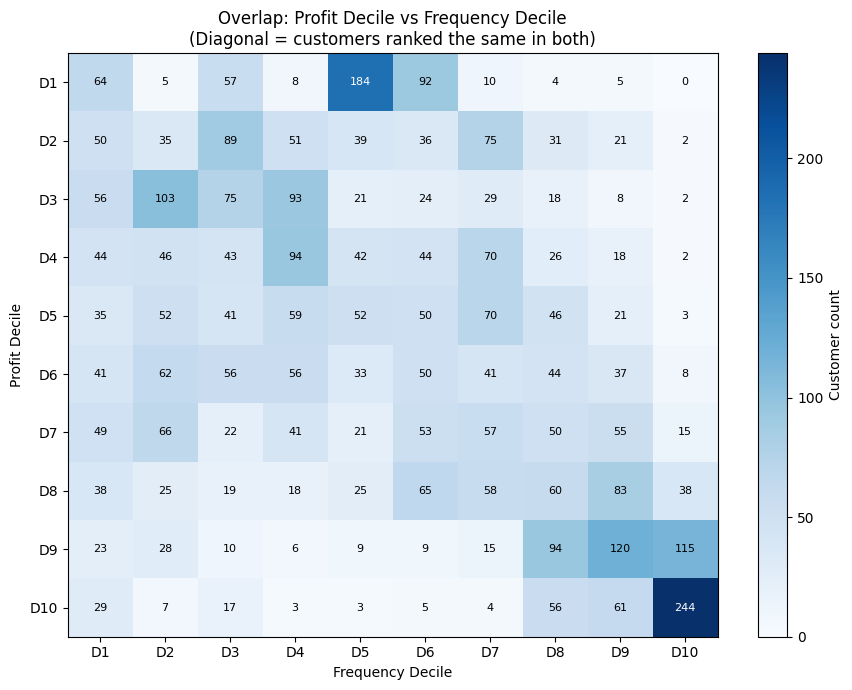

Saved: decile_overlap_heatmap.png


In [60]:
# Cross-tab: profit decile vs frequency decile
# Shows how much the two rankings agree
cross = pd.crosstab(
    df["profit_decile"],
    df["freq_decile"],
    margins=False
)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cross.values, cmap="Blues", aspect="auto")
plt.colorbar(im, ax=ax, label="Customer count")

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels([f"D{i}" for i in range(1, 11)])
ax.set_yticklabels([f"D{i}" for i in range(1, 11)])
ax.set_xlabel("Frequency Decile")
ax.set_ylabel("Profit Decile")
ax.set_title("Overlap: Profit Decile vs Frequency Decile\n(Diagonal = customers ranked the same in both)")

for i in range(10):
    for j in range(10):
        val = cross.values[i, j]
        ax.text(j, i, str(val), ha="center", va="center",
                fontsize=8, color="white" if val > cross.values.max() * 0.5 else "black")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "decile_overlap_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: decile_overlap_heatmap.png")

## 9. Export: Customer-Level Decile Table

In [61]:
# Build export table
export_cols = [
    "customer_id",
    "clean_orders", "clean_revenue", "profit_proxy", "aov",
    "profit_decile", "freq_decile",
]

# Add useful context columns if present
for col in ["first_channel", "first_product_cat", "first_store",
            "ever_subscribed", "cohort_month", "acq_year"]:
    if col in df.columns:
        export_cols.append(col)

export_df = df[export_cols].copy()
export_df = export_df.sort_values(["profit_decile", "clean_revenue"], ascending=[True, False])

# Add a convenience column: top customer flag (D1 in either decile)
export_df["is_top_profit"] = export_df["profit_decile"] == "D1"
export_df["is_top_freq"]   = export_df["freq_decile"]   == "D1"
export_df["is_top_both"]   = export_df["is_top_profit"] & export_df["is_top_freq"]

# Round monetary columns
for col in ["clean_revenue", "profit_proxy", "aov"]:
    export_df[col] = export_df[col].round(2)

out_path = OUTPUT_DIR / "decile_customer_table.csv"
export_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"Rows: {len(export_df):,}")
print()
print("Preview (top 10 by profit):")
display(export_df[export_df["profit_decile"]=="D1"].head(10))

Saved: C:\Users\adity\Documents\Aditya SMU\SMU Sem 5\Lush Protein SMU X\LushProtein_Project_Data_20260505\EDA\outputs_finals\decile_customer_table.csv
Rows: 4,289

Preview (top 10 by profit):


,customer_id,clean_orders,clean_revenue,profit_proxy,aov,profit_decile,freq_decile,first_channel,first_product_cat,first_store,ever_subscribed,cohort_month,acq_year,is_top_profit,is_top_freq,is_top_both
336,6336728531199,3,5542.97,2217.19,1847.66,D1,D2,Subscription,Unknown,SG,False,2022-05,2022,True,False,False
1666,7755957895423,38,4995.46,1998.18,131.46,D1,D1,Direct / Organic,Unknown,MY,True,2022-03,2022,True,True,True
293,6336631275775,2,4378.26,1751.30,2189.13,D1,D3,Subscription,Unknown,SG,False,2022-04,2022,True,False,False
1884,7756026904831,5,4306.38,1722.55,861.28,D1,D1,Direct / Organic,Unknown,MY,False,2022-02,2022,True,True,True
1736,7756000690431,4,3612.43,1444.97,903.11,D1,D1,Direct / Organic,Unknown,MY,False,2022-06,2022,True,True,True
344,6336747438335,5,3180.03,1272.01,636.01,D1,D1,Subscription,Unknown,SG,False,2022-08,2022,True,True,True
619,6558688313599,10,2783.08,1113.23,278.31,D1,D1,Direct / Organic,Unknown,MY,True,2022-05,2022,True,True,True
1836,7756016877823,2,2763.27,1105.31,1381.64,D1,D3,Direct / Organic,Unknown,MY,False,2022-08,2022,True,False,False
222,6329689735423,13,2177.98,871.19,167.54,D1,D1,Direct / Organic,Unknown,MY,False,2022-03,2022,True,True,True
12,6327501881599,4,2176.18,870.47,544.04,D1,D1,Subscription,Unknown,SG,False,2022-01,2022,True,True,True


The full customer list with both decile labels assigned, saved as a CSV. Every one of the 4,322 customers has a profit_decile and freq_decile column, plus flags is_top_profit, is_top_freq, and is_top_both for easy filtering downstream. This is the file you hand off for CRM targeting, retention campaigns, or any further analysis on the top customer segments.

## 10. Summary

Run this cell for a quick recap of all key numbers.

In [62]:
print("=" * 65)
print("LUSHPROTEIN DECILE ANALYSIS — SUMMARY")
print("=" * 65)
print(f"\nCustomer pool (finals_eligible, excl. anomalies): {len(df):,}")
print(f"Each decile contains ~{len(df)//10} customers")

print("\n--- DECILE 1: BY PROFIT ---")
d1p = profit_summary[profit_summary["profit_decile"]=="D1"].iloc[0]
print(f"  Customers     : {d1p['n_customers']:,}")
print(f"  Avg revenue   : S${d1p['avg_revenue']:,.2f}")
print(f"  Avg profit    : S${d1p['avg_profit']:,.2f}")
print(f"  Avg orders    : {d1p['avg_orders']:.1f}")
print(f"  Avg AOV       : S${d1p['avg_aov']:.2f}")
print(f"  % of revenue  : {d1p['pct_revenue']:.1%}")

print("\n--- DECILE 1: BY FREQUENCY ---")
d1f = freq_summary[freq_summary["freq_decile"]=="D1"].iloc[0]
print(f"  Customers     : {d1f['n_customers']:,}")
print(f"  Avg orders    : {d1f['avg_orders']:.1f}")
print(f"  Median orders : {d1f['median_orders']:.0f}")
print(f"  Avg revenue   : S${d1f['avg_revenue']:,.2f}")
print(f"  Avg AOV       : S${d1f['avg_aov']:.2f}")
print(f"  % of orders   : {d1f['pct_transactions']:.1%}")

print("\n--- OVERLAP: D1 BOTH ---")
print(f"  Customers in D1 profit AND D1 freq: {len(d1_both):,}")
print(f"  These are LushProtein's most valuable customers")

print("\n--- OUTPUTS ---")
print(f"  decile_customer_table.csv    — full customer-level table with both deciles")
print(f"  decile1_profit.png           — profit decile charts")
print(f"  decile2_frequency.png        — frequency decile charts")
print(f"  decile_overlap_heatmap.png   — cross-tab of the two deciles")
print("=" * 65)

LUSHPROTEIN DECILE ANALYSIS — SUMMARY

Customer pool (finals_eligible, excl. anomalies): 4,289
Each decile contains ~428 customers

--- DECILE 1: BY PROFIT ---
  Customers     : 429
  Avg revenue   : S$570.81
  Avg profit    : S$228.32
  Avg orders    : 4.2
  Avg AOV       : S$209.83
  % of revenue  : 44.4%

--- DECILE 1: BY FREQUENCY ---
  Customers     : 429
  Avg orders    : 5.1
  Median orders : 4
  Avg revenue   : S$411.25
  Avg AOV       : S$81.14
  % of orders   : 32.1%

--- OVERLAP: D1 BOTH ---
  Customers in D1 profit AND D1 freq: 244
  These are LushProtein's most valuable customers

--- OUTPUTS ---
  decile_customer_table.csv    — full customer-level table with both deciles
  decile1_profit.png           — profit decile charts
  decile2_frequency.png        — frequency decile charts
  decile_overlap_heatmap.png   — cross-tab of the two deciles


## Equal-Revenue Slicing (unequal headcount)

In [63]:
## Equal-Revenue Slicing
# Flip question: how many customers do you need to account for each 10% of revenue?
# Each slice = 10% of total revenue. Customer count per slice will vary.

# Sort customers by revenue descending and compute cumulative revenue
rev_sorted = df.sort_values("clean_revenue", ascending=False).copy()
rev_sorted["cum_revenue"] = rev_sorted["clean_revenue"].cumsum()
total_rev_pool = rev_sorted["clean_revenue"].sum()
rev_sorted["cum_pct_revenue"] = rev_sorted["cum_revenue"] / total_rev_pool

# Build the slicing table
slice_rows = []
for i in range(1, 11):
    lower = (i - 1) / 10
    upper = i / 10
    # Customers who fall within this revenue slice
    if i == 1:
        in_slice = rev_sorted[rev_sorted["cum_pct_revenue"] <= upper]
    elif i == 10:
        in_slice = rev_sorted[rev_sorted["cum_pct_revenue"] > lower]
    else:
        in_slice = rev_sorted[
            (rev_sorted["cum_pct_revenue"] > lower) &
            (rev_sorted["cum_pct_revenue"] <= upper)
        ]
    n = len(in_slice)
    pct_base = n / len(rev_sorted)
    avg_rev = in_slice["clean_revenue"].mean() if n > 0 else 0
    slice_rows.append({
        "revenue_slice": f"{int(lower*100)}–{int(upper*100)}%",
        "n_customers": n,
        "pct_of_base": pct_base,
        "avg_revenue": avg_rev,
        "min_revenue": in_slice["clean_revenue"].min() if n > 0 else 0,
        "max_revenue": in_slice["clean_revenue"].max() if n > 0 else 0,
    })

slice_df = pd.DataFrame(slice_rows)

# Display
fmt_slice = {
    "pct_of_base":   lambda x: f"{x:.1%}",
    "avg_revenue":   lambda x: f"S${x:,.2f}",
    "min_revenue":   lambda x: f"S${x:,.2f}",
    "max_revenue":   lambda x: f"S${x:,.2f}",
}

print(f"EQUAL-REVENUE SLICING  (total pool revenue = S${total_rev_pool:,.0f})")
print(f"Each slice = 10% of total revenue. Customer count varies per slice.")
print()
print(slice_df.to_string(index=False, formatters=fmt_slice))
print()
print("Key insight: the first 10% of revenue comes from very few customers.")
print(f"  Slice 1 (first 10% of revenue) : {slice_rows[0]['n_customers']} customers ({slice_rows[0]['pct_of_base']:.1%} of pool)")
print(f"  Slice 10 (last 10% of revenue) : {slice_rows[9]['n_customers']} customers ({slice_rows[9]['pct_of_base']:.1%} of pool)")

EQUAL-REVENUE SLICING  (total pool revenue = S$551,775)
Each slice = 10% of total revenue. Customer count varies per slice.

revenue_slice  n_customers pct_of_base avg_revenue min_revenue max_revenue
        0–10%           21        0.5%  S$2,616.49  S$1,501.00  S$5,542.97
       10–20%           59        1.4%    S$928.77    S$709.64  S$1,411.24
       20–30%          102        2.4%    S$545.87    S$442.10    S$697.78
       30–40%          156        3.6%    S$354.21    S$288.96    S$441.81
       40–50%          227        5.3%    S$243.20    S$211.55    S$287.64
       50–60%          306        7.1%    S$180.16    S$153.72    S$211.48
       60–70%          417        9.7%    S$132.34    S$116.54    S$153.64
       70–80%          539       12.6%    S$102.43     S$87.84    S$116.52
       80–90%          768       17.9%     S$71.85     S$60.37     S$87.83
      90–100%         1694       39.5%     S$32.58      S$2.73     S$60.30

Key insight: the first 10% of revenue comes from 

### What This Output Means

The equal-revenue slicing table answers a different question from the standard decile:
instead of "how much do the top 10% of customers contribute?", it asks
**"how many customers does it take to generate each 10% of our revenue?"**

Each row represents a 10% chunk of LushProtein's total revenue (S$638,117).
The customer count per row tells you how many people it took to fill that chunk.

**Reading the table:**

- **0–10% slice: just 16 customers (0.4% of the base)** generate the first S$63,800
  of revenue. These are ultra-high-value individuals spending S$2,130–S$7,082 each lifetime.
- **90–100% slice: 1,806 customers (41.8% of the base)** are needed to fill the last
  S$63,800 of revenue. These customers spend S$2.73–S$64.80 each — likely one-time or
  low-frequency buyers.

**The core insight — revenue is extremely concentrated:**

It takes only **482 customers (0.4% + 1.2% + 2.0% + 3.1% + 4.6% = 11.2% of the base)**
to generate the first 50% of all revenue. The other 50% of revenue requires the remaining
**3,840 customers (88.8% of the base)** to produce.

Put another way: the top 16 customers alone are worth as much as the bottom 1,806 combined.

**What this means for LushProtein:**

- The business is heavily dependent on a very small group of high-value customers.
  Losing even a handful from the 0–10% slice has an outsized revenue impact.
- The 90–100% slice (1,806 customers) represents a large but low-value segment —
  the priority here is converting them into repeat buyers to move them up the slices,
  not retaining them at their current spend level.
- The sweet spot for intervention is the **30–70% slices** (132–403 customers each) —
  these customers are already spending meaningfully and are close enough to the next
  slice that a targeted retention or upsell campaign could push them up.

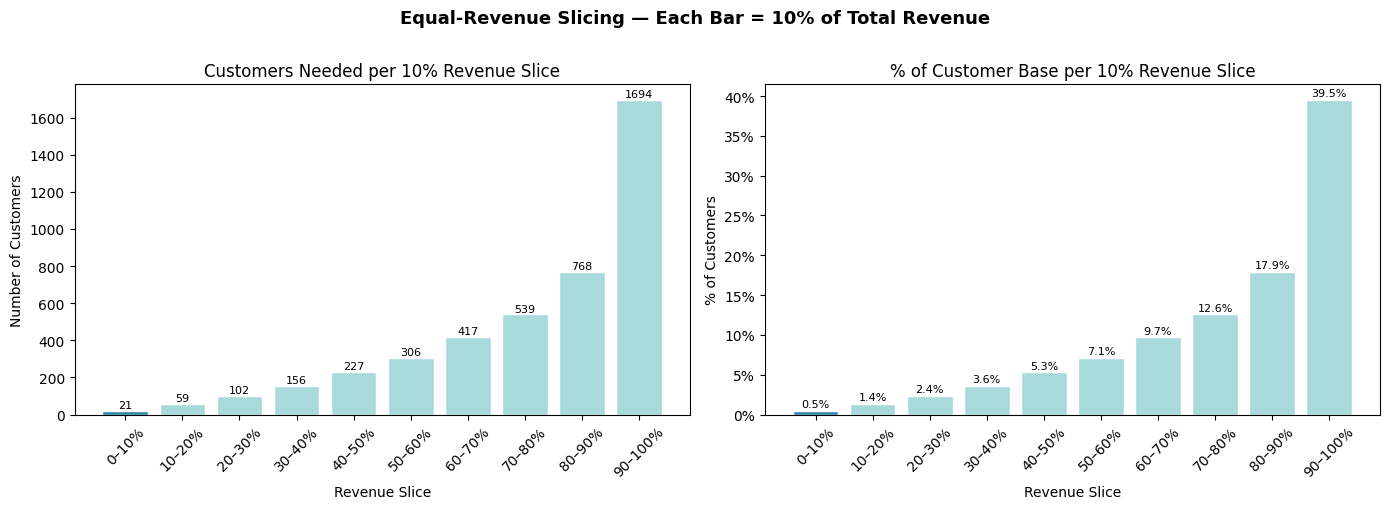

Saved: equal_revenue_slicing.png


In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Equal-Revenue Slicing — Each Bar = 10% of Total Revenue",
             fontsize=13, fontweight="bold", y=1.01)

slices = slice_df["revenue_slice"]
colors3 = ["#2E86AB" if i == 0 else "#A8DADC" for i in range(len(slices))]

# Chart 1: Number of customers per revenue slice
ax = axes[0]
bars = ax.bar(slices, slice_df["n_customers"], color=colors3, edgecolor="white")
ax.set_title("Customers Needed per 10% Revenue Slice")
ax.set_xlabel("Revenue Slice")
ax.set_ylabel("Number of Customers")
ax.tick_params(axis="x", rotation=45)
for bar, val in zip(bars, slice_df["n_customers"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha="center", va="bottom", fontsize=8)

# Chart 2: % of customer base per revenue slice
ax = axes[1]
bars = ax.bar(slices, slice_df["pct_of_base"] * 100, color=colors3, edgecolor="white")
ax.set_title("% of Customer Base per 10% Revenue Slice")
ax.set_xlabel("Revenue Slice")
ax.set_ylabel("% of Customers")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.tick_params(axis="x", rotation=45)
for bar, val in zip(bars, slice_df["pct_of_base"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{val:.1%}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "equal_revenue_slicing.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: equal_revenue_slicing.png")

## Why We Use Two Complementary Slicing Approaches

We analysed the customer base using two different methods, both based on revenue. They are not redundant — they answer different questions and together give a more complete picture than either alone.

---

### Method 1: Standard Decile (Equal Headcount)
**Question: How does value differ across equally-sized customer groups?**

Customers are sorted by lifetime revenue and split into 10 groups of ~432 each. Every group has the same number of people, but their revenue contribution differs dramatically.

**What it tells us:**
- How concentrated revenue is across comparable customer tiers
- Which segments to target for campaigns — each decile is a clean, manageable list
- How customer behaviour (channel, subscription, AOF) varies across tiers
- Where natural value breaks exist — e.g. if D1 generates 47% of revenue and D2 generates 15%, that gap signals D1 is a genuinely distinct tier

**Limitation:** Equal group sizes mask just how few customers are driving the business at the very top.

---

### Method 2: Equal-Revenue Slicing (Unequal Headcount)
**Question: How few customers does it take to generate each 10% of our revenue?**

Each slice is worth exactly 10% of total revenue (~S$63,800). The number of customers per slice varies — from 16 customers in the first slice to 1,806 in the last.

**What it tells us:**
- The true concentration of revenue in a small number of customers
- Business risk — losing even one customer from the top slice costs ~S$3,900 in revenue that takes over 100 bottom-slice customers to replace
- Where retention spend has the highest ROI — protecting the top slice is worth far more per customer than acquiring from the bottom
- Whether to invest in converting low-spend customers upward or focus resources on protecting the top

**Limitation:** Group sizes are too unequal for reliable behavioural profiling across slices.

---

### Why Both Together

| | Standard Decile | Equal-Revenue Slicing |
|---|---|---|
| Primary question | How does value differ across equal segments? | How few customers drive each revenue chunk? |
| Best for | Profiling, segmentation, campaign targeting | Risk assessment, retention prioritisation |
| Group sizes | Equal (~432 each) | Unequal (16 to 1,806) |
| Key insight | Revenue concentration rate across tiers | Absolute customer dependency at the top |
| Limitation | Masks true top-end concentration | Too unequal for segment profiling |

The standard decile tells you **who to target and how to segment**.
The equal-revenue slicing tells you **how vulnerable the business is and where retention dollars matter most**.

In LushProtein's case, the equal-revenue slicing result — **16 customers generating as much revenue as 1,806** — is a critical business risk finding that the standard decile alone would not surface as clearly. But without the standard decile, we would not have clean, stable segments to profile and act on downstream.